In [1]:
!pip install kaggle
!kaggle datasets download -d andrewmvd/face-mask-detection


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0




  0%|          | 0.00/398M [00:00<?, ?B/s]
  0%|          | 1.00M/398M [00:01<11:33, 600kB/s]
  1%|          | 2.00M/398M [00:02<06:24, 1.08MB/s]
  1%|          | 3.00M/398M [00:02<04:11, 1.64MB/s]
  1%|          | 4.00M/398M [00:02<03:03, 2.25MB/s]
  2%|▏         | 6.00M/398M [00:02<01:56, 3.52MB/s]
  2%|▏         | 8.00M/398M [00:03<01:21, 5.03MB/s]
  2%|▏         | 9.00M/398M [00:03<01:11, 5.70MB/s]
  3%|▎         | 10.0M/398M [00:03<01:04, 6.33MB/s]
  3%|▎         | 11.0M/398M [00:03<01:01, 6.64MB/s]
  3%|▎         | 12.0M/398M [00:03<00:55, 7.24MB/s]
  3%|▎         | 13.0M/398M [00:03<00:51, 7.85MB/s]
  4%|▎         | 14.0M/398M [00:03<00:51, 7.82MB/s]
  4%|▍         | 16.0M/398M [00:03<00:44, 8.96MB/s]
  5%|▍         | 18.0M/398M [00:04<00:41, 9.59MB/s]
  5%|▌         | 20.0M/398M [00:04<00:38, 10.2MB/s]
  6%|▌         | 22.0M/398M [00:04<00:37, 10.6MB/s]
  6%|▌         | 24.0M/398M [00:04<00:36, 10.8MB/s]
  7%|▋         | 26.0M/398M [00:04<00:35, 11.0MB/s]
  7%|▋         | 28.0

In [10]:
import zipfile
with zipfile.ZipFile("face-mask-detection.zip", "r") as f:
    f.extractall("data")

In [11]:
import os
images = sorted(
    os.listdir("data/images"),
    key=lambda x: int(''.join(filter(str.isdigit, x)))
)

print(images[:5])

['maksssksksss0.png', 'maksssksksss1.png', 'maksssksksss2.png', 'maksssksksss3.png', 'maksssksksss4.png']


In [13]:
!pip install ultralytics opencv-python matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import cv2
import xml.etree.ElementTree as ET
import random
import shutil
import matplotlib.pyplot as plt

In [12]:
IMAGE_DIR = "data/images"
ANNOTATION_DIR = "data/annotations"
LABEL_DIR = "data/labels"

os.makedirs(LABEL_DIR, exist_ok=True)

In [13]:
label_map= {
    "with_mask": 0,
    "without_mask": 1,
    "mask_weared_incorrect": 2
}

for file in os.listdir(ANNOTATION_DIR):
    tree = ET.parse(os.path.join(ANNOTATION_DIR, file))
    root = tree.getroot()
    
    img_file = file.replace(".xml", ".png")
    img_path = os.path.join(IMAGE_DIR, img_file)
    
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    
    h, w, _ = img.shape
    txt_file=img_file.replace(".png", ".txt")
    
    with open(os.path.join(LABEL_DIR, txt_file), "w") as y:
        for obj in root.findall("object"):
            label = obj.find("name").text
            bbox = obj.find("bndbox") 

            xmin = int(bbox.find("xmin").text)
            ymin = int(bbox.find("ymin").text)
            xmax = int(bbox.find("xmax").text)
            ymax = int(bbox.find("ymax").text)

            x_center = ((xmin + xmax) / 2) / w
            y_center = ((ymin + ymax) / 2) / h
            width = (xmax - xmin) / w
            height = (ymax - ymin) / h

            yolo_label = label_map[label]

            y.write(f"{yolo_label} {x_center} {y_center} {width} {height}\n")
    

In [15]:
images = os.listdir(IMAGE_DIR)
random.shuffle(images)

split = int(0.8 * len(images))

train = images[:split]
val=images[split:]

for split_name, split_data in [("train", train), ("val", val)]:
    os.makedirs(f"dataset/images/{split_name}", exist_ok=True)
    os.makedirs(f"dataset/labels/{split_name}", exist_ok=True)
    
    for img in split_data:
        shutil.copy(os.path.join(IMAGE_DIR, img), f"dataset/images/{split_name}/{img}")
        
        txt = img.replace(".png", ".txt")
        shutil.copy(os.path.join(LABEL_DIR, txt), f"dataset/labels/{split_name}/{txt}")

In [16]:
with open("data.yaml", "w") as f:
    f.write("""
path: dataset

train: images/train
val: images/val

names:
  0: with_mask
  1: without_mask
  2: mask_weared_incorrect
""")

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data = "data.yaml",
    epochs = 3,
    imgsz = 416    
)

New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.30  Python-3.13.2 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=

KeyboardInterrupt: 

In [4]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")


image 1/171 c:\Users\gsksa\face-mask-detection\dataset\images\val\maksssksksss108.png: 256x416 5 with_masks, 95.8ms
image 2/171 c:\Users\gsksa\face-mask-detection\dataset\images\val\maksssksksss110.png: 288x416 11 with_masks, 12 without_masks, 87.0ms
image 3/171 c:\Users\gsksa\face-mask-detection\dataset\images\val\maksssksksss114.png: 256x416 1 with_mask, 1 without_mask, 75.7ms
image 4/171 c:\Users\gsksa\face-mask-detection\dataset\images\val\maksssksksss115.png: 288x416 7 with_masks, 88.1ms
image 5/171 c:\Users\gsksa\face-mask-detection\dataset\images\val\maksssksksss12.png: 288x416 7 with_masks, 75.5ms
image 6/171 c:\Users\gsksa\face-mask-detection\dataset\images\val\maksssksksss123.png: 320x416 2 with_masks, 93.4ms
image 7/171 c:\Users\gsksa\face-mask-detection\dataset\images\val\maksssksksss13.png: 256x416 5 with_masks, 84.5ms
image 8/171 c:\Users\gsksa\face-mask-detection\dataset\images\val\maksssksksss137.png: 416x416 2 with_masks, 2 without_masks, 108.6ms
image 9/171 c:\Users\

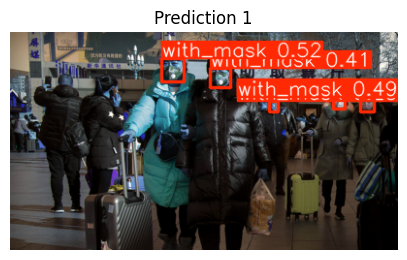

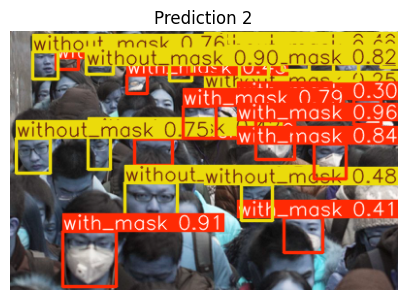

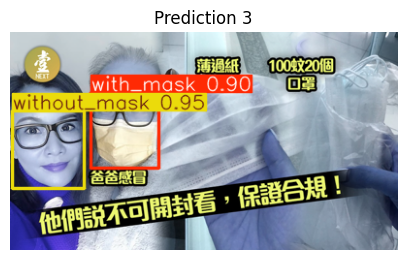

In [7]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# load model
model = YOLO("runs/detect/train/weights/best.pt")

# run prediction
results = model.predict("dataset/images/val")

# show only first 3 images
for i in range(3):
    img = results[i].plot()   # draw boxes
    
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f"Prediction {i+1}")
    plt.axis("off")